In [1]:
import pandas as pd
import numpy as np

features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_fusion = pd.merge(features, price, on="hotel_id")

df_fusion = df_fusion.sort_values(["hotel_id", "year", "month"]).reset_index(drop=True)

df_fusion = df_fusion.drop(columns=[
    "country",
    "city_actual",
    "center1label",
    "center2label",
    "neighbourhood"
], errors="ignore")

df_fusion = pd.get_dummies(df_fusion, columns=[
    "city",
    "accommodation_type",
    "offer_cat"
], drop_first=False)

df_fusion = df_fusion[df_fusion["price"] < 2000].dropna().reset_index(drop=True)

print(df_fusion.shape)
print(df_fusion.head())

(110146, 89)
   hotel_id  distance  stars  rating  rating_reviewcount  ratingta  \
0         1       3.1    4.0     4.3              1030.0       4.0   
1         1       3.1    4.0     4.3              1030.0       4.0   
2         1       3.1    4.0     4.3              1030.0       4.0   
3         1       3.1    4.0     4.3              1030.0       4.0   
4         1       3.1    4.0     4.3              1030.0       4.0   

   ratingta_count  distance_alter  price  offer  ...  \
0          1115.0             3.6    172      0  ...   
1          1115.0             3.6    114      1  ...   
2          1115.0             3.6    122      1  ...   
3          1115.0             3.6    552      1  ...   
4          1115.0             3.6    122      1  ...   

   accommodation_type_Pension  accommodation_type_Pousada  \
0                           0                           0   
1                           0                           0   
2                           0                 

In [2]:
sequence_length = 6

X_seq = []
X_tab = []
y_fusion = []

for hotel_id, group in df_fusion.groupby("hotel_id"):
    group = group.sort_values(["year", "month"]).reset_index(drop=True)
    
    prices = group["price"].values
    
    tab_features = group.drop(columns=["price", "hotel_id"]).values
    
    for i in range(len(group) - sequence_length):
        X_seq.append(prices[i:i+sequence_length])
        
        X_tab.append(tab_features[i+sequence_length])
        
        y_fusion.append(prices[i+sequence_length])

X_seq = np.array(X_seq)
X_tab = np.array(X_tab)
y_fusion = np.array(y_fusion)

print("X_seq shape:", X_seq.shape)
print("X_tab shape:", X_tab.shape)
print("y_fusion shape:", y_fusion.shape)

X_seq shape: (32263, 6)
X_tab shape: (32263, 87)
y_fusion shape: (32263,)


In [3]:
from sklearn.model_selection import train_test_split

X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train_fusion, y_test_fusion = train_test_split(
    X_seq, X_tab, y_fusion,
    test_size=0.2,
    random_state=42
)

D:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

scaler_tab = StandardScaler()
X_tab_train_scaled = scaler_tab.fit_transform(X_tab_train)
X_tab_test_scaled = scaler_tab.transform(X_tab_test)

mlp_fusion = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=200,
    early_stopping=True,
    random_state=42
)

mlp_fusion.fit(X_tab_train_scaled, y_train_fusion)

pred_mlp_fusion = mlp_fusion.predict(X_tab_test_scaled)

rmse_mlp_fusion = np.sqrt(mean_squared_error(y_test_fusion, pred_mlp_fusion))
print("Fusion-aligned MLP RMSE:", rmse_mlp_fusion)

Fusion-aligned MLP RMSE: 63.615936725017875


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler_seq = MinMaxScaler()

y_train_fusion_2d = y_train_fusion.reshape(-1, 1)
scaler_seq.fit(y_train_fusion_2d)

X_seq_train_scaled = scaler_seq.transform(X_seq_train.reshape(-1, 1)).reshape(X_seq_train.shape[0], X_seq_train.shape[1], 1)
X_seq_test_scaled = scaler_seq.transform(X_seq_test.reshape(-1, 1)).reshape(X_seq_test.shape[0], X_seq_test.shape[1], 1)


y_train_seq_scaled = scaler_seq.transform(y_train_fusion.reshape(-1, 1)).flatten()
y_test_seq_scaled = scaler_seq.transform(y_test_fusion.reshape(-1, 1)).flatten()

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_fusion = Sequential()
lstm_fusion.add(LSTM(64, input_shape=(sequence_length, 1)))
lstm_fusion.add(Dense(1))

lstm_fusion.compile(optimizer="adam", loss="mse")

lstm_fusion.fit(
    X_seq_train_scaled,
    y_train_seq_scaled,
    epochs=30,
    batch_size=32,
    verbose=1
)

pred_lstm_scaled = lstm_fusion.predict(X_seq_test_scaled)

pred_lstm_fusion = scaler_seq.inverse_transform(pred_lstm_scaled).flatten()

rmse_lstm_fusion = np.sqrt(mean_squared_error(y_test_fusion, pred_lstm_fusion))
print("Fusion-aligned LSTM RMSE:", rmse_lstm_fusion)

Epoch 1/30


D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


807/807 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0018
Epoch 2/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.7525e-04
Epoch 3/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.3996e-04
Epoch 4/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.6625e-04
Epoch 5/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.0906e-04
Epoch 6/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9106e-04
Epoch 7/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.7652e-04
Epoch 8/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.1680e-04
Epoch 9/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.8315e-04
Epoch 10/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.2764e-04
Epoch 11/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.8548e-04
Epoch 12/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9458e-04
Epoch 13/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.5611e-04
Epoch 14/30
807/807 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9653e-04
Epoch 15/30
807/

In [11]:
weights = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

best_rmse = float("inf")
best_w = None
best_pred = None

for w in weights:
    pred_fusion = w * pred_lstm_fusion + (1 - w) * pred_mlp_fusion
    rmse_fusion = np.sqrt(mean_squared_error(y_test_fusion, pred_fusion))
    
    print(f"LSTM weight={w:.1f}, Fusion RMSE={rmse_fusion:.4f}")
    
    if rmse_fusion < best_rmse:
        best_rmse = rmse_fusion
        best_w = w
        best_pred = pred_fusion

print("Best fusion weight:", best_w)
print("Best fusion RMSE:", best_rmse)

LSTM weight=0.1, Fusion RMSE=59.9500
LSTM weight=0.2, Fusion RMSE=56.6821
LSTM weight=0.3, Fusion RMSE=53.8849
LSTM weight=0.4, Fusion RMSE=51.6347
LSTM weight=0.5, Fusion RMSE=50.0057
LSTM weight=0.6, Fusion RMSE=49.0596
LSTM weight=0.7, Fusion RMSE=48.8362
LSTM weight=0.8, Fusion RMSE=49.3453
LSTM weight=0.9, Fusion RMSE=50.5647
Best fusion weight: 0.7
Best fusion RMSE: 48.83618132881653


In [12]:
fusion_results_df = pd.DataFrame({
    "Model": [
        "MLP (aligned)",
        "LSTM (aligned)",
        "MLP + LSTM Fusion"
    ],
    "RMSE": [
        rmse_mlp_fusion,
        rmse_lstm_fusion,
        best_rmse
    ]
})

print(fusion_results_df)

               Model       RMSE
0      MLP (aligned)  63.615937
1     LSTM (aligned)  52.444975
2  MLP + LSTM Fusion  48.836181


In [13]:
fusion_results_df = pd.DataFrame({
    "Model": [
        "MLP (aligned)",
        "LSTM (aligned)",
        "MLP + LSTM Fusion"
    ],
    "RMSE": [
        rmse_mlp_fusion,
        rmse_lstm_fusion,
        best_rmse
    ]
})

print(fusion_results_df)

               Model       RMSE
0      MLP (aligned)  63.615937
1     LSTM (aligned)  52.444975
2  MLP + LSTM Fusion  48.836181


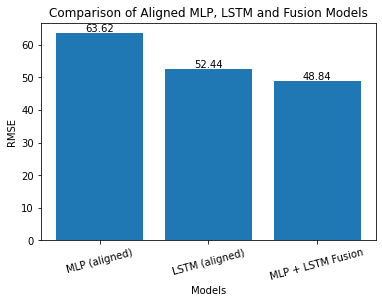

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

fusion_results_df = pd.DataFrame({
    "Model": ["MLP (aligned)", "LSTM (aligned)", "MLP + LSTM Fusion"],
    "RMSE": [63.615937, 52.444975, 48.836181]
})

plt.figure()
bars = plt.bar(fusion_results_df["Model"], fusion_results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
             ha="center", va="bottom")

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Comparison of Aligned MLP, LSTM and Fusion Models")
plt.xticks(rotation=15)
plt.show()

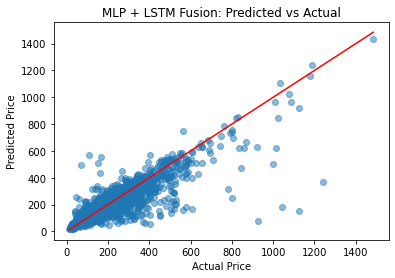

In [15]:
plt.figure()
plt.scatter(y_test_fusion, best_pred, alpha=0.5)

plt.plot(
    [y_test_fusion.min(), y_test_fusion.max()],
    [y_test_fusion.min(), y_test_fusion.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("MLP + LSTM Fusion: Predicted vs Actual")
plt.show()